# Expert LoRA — Learning Curves

Per-step training loss and per-epoch validation losses for all four quadrant experts.  
Data is read directly from `data/experts/training-outputs/` — no model needed.

**Sources:**
- Step-level train loss → `<seed>/<last_checkpoint>/trainer_state.json` (`log_history` entries with a `loss` key)
- Epoch-level val losses → `<seed>/train_log.jsonl` (all three splits: `val_indist`, `val_source`, `val_topic`)

The **best seed** (lowest `val_source_loss`) is drawn with full opacity and labelled; the other two seeds are drawn as lighter background traces to show inter-seed stability.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

ROOT = Path.cwd().resolve()
while not (ROOT / ".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

TRAIN_DIR = ROOT / "data" / "experts" / "training-outputs"
print("repo root:", ROOT)

repo root: /Users/emmamora/Documents/GitHub/political-debiasing-moe


In [2]:
def load_expert(expert: str) -> dict:
    """Return all training data for one expert, keyed by seed integer."""
    expert_dir = TRAIN_DIR / expert
    summary = json.loads((expert_dir / "best_seed_summary.json").read_text())
    best_seed = summary["best_seed"]

    seeds = {}
    for seed_dir in sorted(expert_dir.glob("seed_*")):
        seed_int = int(seed_dir.name.split("_")[1])

        # per-step training loss from the last saved checkpoint
        last_ckpt = sorted(
            [d for d in seed_dir.iterdir() if d.name.startswith("checkpoint-")],
            key=lambda d: int(d.name.split("-")[1]),
        )[-1]
        state = json.loads((last_ckpt / "trainer_state.json").read_text())
        train_steps = [
            (e["step"], e["loss"])
            for e in state["log_history"]
            if "loss" in e
        ]
        steps, train_losses = zip(*train_steps) if train_steps else ([], [])

        # epoch-level val losses
        val_rows = [
            json.loads(line)
            for line in (seed_dir / "train_log.jsonl").read_text().splitlines()
            if line.strip()
        ]

        seeds[seed_int] = {
            "steps": list(steps),
            "train_losses": list(train_losses),
            "val_rows": val_rows,          # list of dicts, one per epoch
            "max_steps": state["max_steps"],
            "num_epochs": state["num_train_epochs"],
        }

    return {
        "expert": expert,
        "best_seed": best_seed,
        "best_val_source": summary["best_val_source_loss"],
        "seeds": seeds,
    }


EXPERTS = ["right_auth", "left_auth", "left_lib", "right_lib"]
data = {e: load_expert(e) for e in EXPERTS}
print("Loaded:", list(data.keys()))

Loaded: ['right_auth', 'left_auth', 'left_lib', 'right_lib']


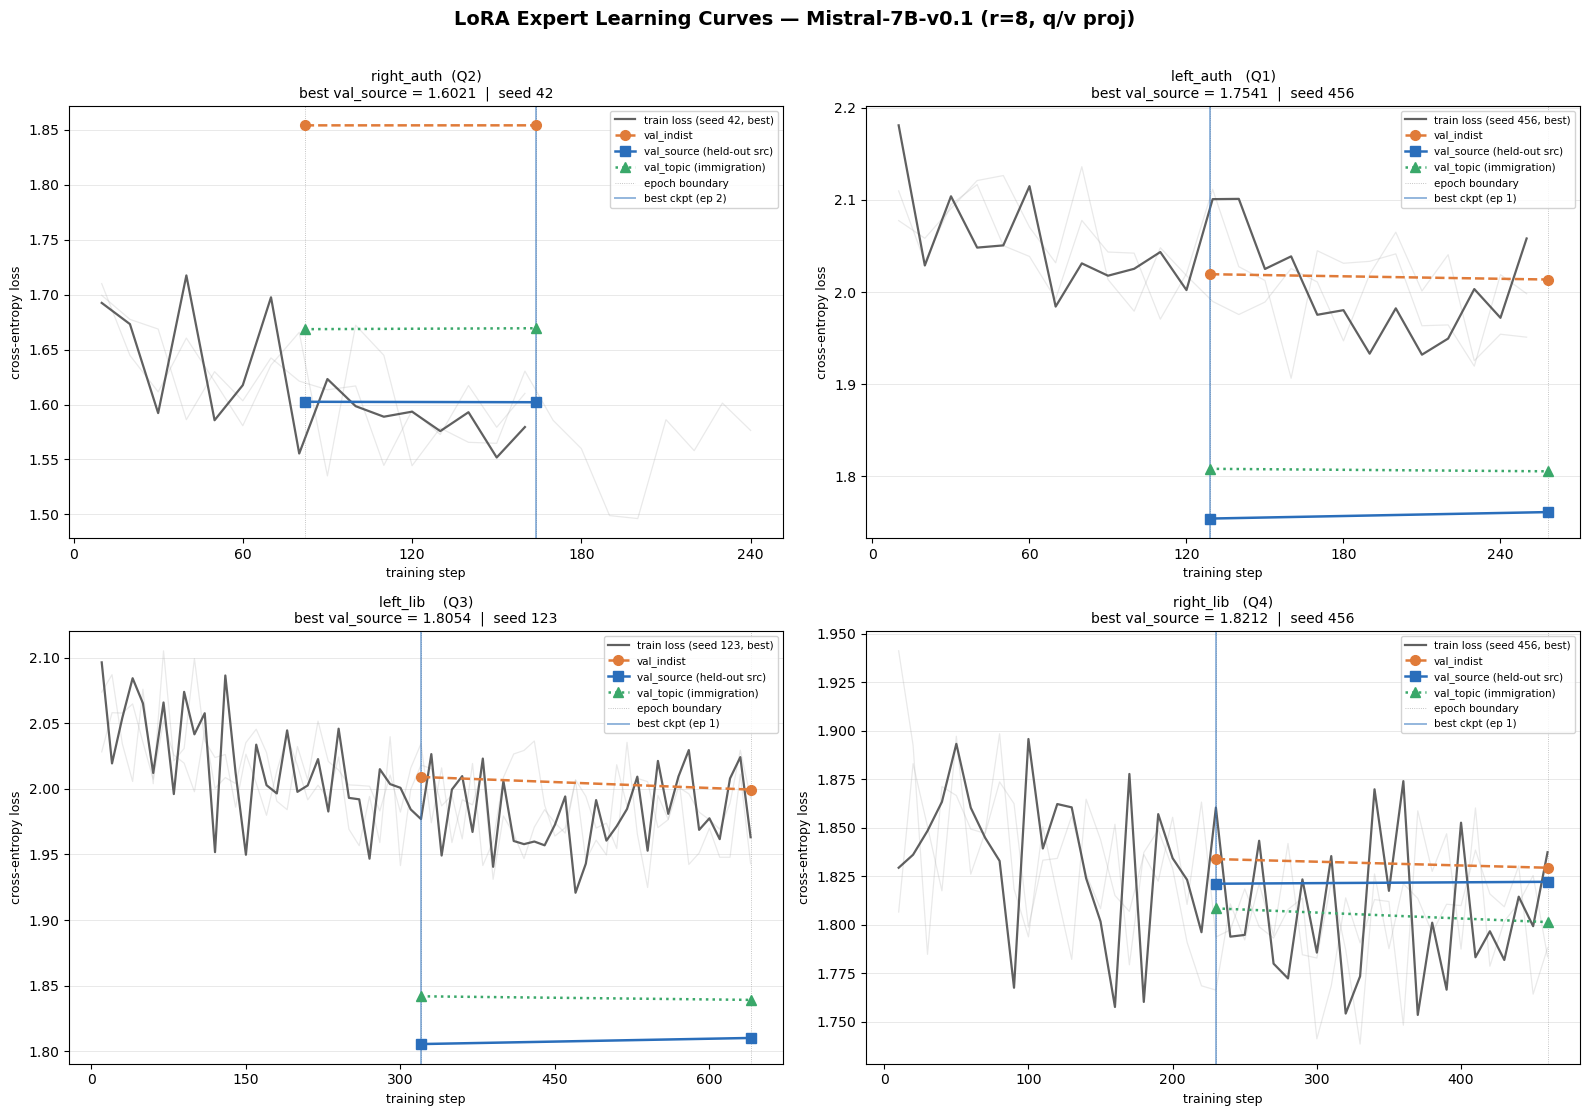

Figure saved to docs/expert_training_curves.png


In [3]:
VAL_STYLES = {
    "val_indist_loss": dict(marker="o", linestyle="--", color="#e07b39", label="val_indist"),
    "val_source_loss": dict(marker="s", linestyle="-",  color="#2a6ebb", label="val_source (held-out src)"),
    "val_topic_loss":  dict(marker="^", linestyle=":",  color="#3aa86a", label="val_topic (immigration)"),
}

EXPERT_LABELS = {
    "right_auth": "right_auth  (Q2)",
    "left_auth":  "left_auth   (Q1)",
    "left_lib":   "left_lib    (Q3)",
    "right_lib":  "right_lib   (Q4)",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "LoRA Expert Learning Curves — Mistral-7B-v0.1 (r=8, q/v proj)",
    fontsize=14, fontweight="bold", y=1.01,
)

for ax, expert in zip(axes.flat, EXPERTS):
    d = data[expert]
    best_seed = d["best_seed"]

    # steps per epoch (same for all seeds of this expert)
    any_seed = next(iter(d["seeds"].values()))
    steps_per_epoch = any_seed["max_steps"] / any_seed["num_epochs"]

    for seed, sd in d["seeds"].items():
        is_best = seed == best_seed
        alpha_train = 0.85 if is_best else 0.25
        lw_train    = 1.6  if is_best else 0.9
        color_train = "#444" if is_best else "#aaa"
        seed_label  = f"train loss (seed {seed}, best)" if is_best else None

        # training loss curve
        ax.plot(
            sd["steps"], sd["train_losses"],
            color=color_train, alpha=alpha_train, lw=lw_train,
            label=seed_label, zorder=2 if is_best else 1,
        )

        # val losses at epoch boundaries — only for best seed to keep plot readable
        if is_best:
            for split_key, style in VAL_STYLES.items():
                xs = [row["global_step"] for row in sd["val_rows"]]
                ys = [row[split_key] for row in sd["val_rows"]]
                ax.plot(xs, ys, ms=7, lw=1.8, zorder=3, **style)

    # epoch boundary verticals
    num_epochs_saved = len(any_seed["val_rows"])
    for ep in range(1, num_epochs_saved + 1):
        ax.axvline(
            ep * steps_per_epoch, color="grey", lw=0.6, ls=":", alpha=0.6,
            label="epoch boundary" if ep == 1 else None,
        )

    # best-checkpoint marker
    best_sd = d["seeds"][best_seed]
    best_ep_row = min(
        best_sd["val_rows"],
        key=lambda r: r["val_source_loss"],
    )
    ax.axvline(
        best_ep_row["global_step"], color="#2a6ebb", lw=1.4, ls="-",
        alpha=0.5, label=f"best ckpt (ep {best_ep_row['epoch']:.0f})",
    )

    ax.set_title(
        f"{EXPERT_LABELS[expert]}\n"
        f"best val_source = {d['best_val_source']:.4f}  |  seed {best_seed}",
        fontsize=10,
    )
    ax.set_xlabel("training step", fontsize=9)
    ax.set_ylabel("cross-entropy loss", fontsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
    ax.legend(fontsize=7.5, loc="upper right", framealpha=0.85)
    ax.grid(axis="y", lw=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(ROOT / "docs" / "expert_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to docs/expert_training_curves.png")

In [4]:
# Numeric summary of epoch-end losses for all seeds
import pandas as pd

rows = []
for expert in EXPERTS:
    d = data[expert]
    for seed, sd in d["seeds"].items():
        for row in sd["val_rows"]:
            rows.append({
                "expert": expert,
                "seed": seed,
                "best_seed": seed == d["best_seed"],
                "epoch": int(row["epoch"]),
                "train": round(row["train_loss"], 4),
                "val_indist": round(row["val_indist_loss"], 4),
                "val_source": round(row["val_source_loss"], 4),
                "val_topic": round(row["val_topic_loss"], 4),
            })

df = pd.DataFrame(rows)
df_best = df[df["best_seed"]].drop(columns="best_seed").reset_index(drop=True)
print("=== Best-seed epoch-end losses ===")
df_best

=== Best-seed epoch-end losses ===


,expert,seed,epoch,train,val_indist,val_source,val_topic
0,right_auth,42,1,1.5554,1.8541,1.6025,1.6686
1,right_auth,42,2,1.5795,1.8541,1.6021,1.6694
2,left_auth,456,1,2.0021,2.0193,1.7541,1.8081
3,left_auth,456,2,2.0581,2.0136,1.7612,1.8054
4,left_lib,123,1,1.9770,2.0091,1.8054,1.8418
5,left_lib,123,2,1.9632,1.9995,1.8100,1.8391
6,right_lib,456,1,1.8604,1.8339,1.8212,1.8085
7,right_lib,456,2,1.8374,1.8294,1.8222,1.8014


In [5]:
# Inter-seed spread at the best epoch (shows stability)
print("=== All seeds — epoch 1 (shows seed stability) ===")
df[df["epoch"] == 1].drop(columns="best_seed").sort_values(["expert", "seed"]).reset_index(drop=True)

=== All seeds — epoch 1 (shows seed stability) ===


,expert,seed,epoch,train,val_indist,val_source,val_topic
0,left_auth,42,1,2.0178,2.0196,1.7547,1.8076
1,left_auth,123,1,2.0200,2.0195,1.7550,1.8070
2,left_auth,456,1,2.0021,2.0193,1.7541,1.8081
3,left_lib,42,1,2.0183,2.0089,1.8061,1.8415
4,left_lib,123,1,1.9770,2.0091,1.8054,1.8418
5,left_lib,456,1,2.0346,2.0081,1.8068,1.8414
6,right_auth,42,1,1.5554,1.8541,1.6025,1.6686
7,right_auth,123,1,1.6213,1.8559,1.6039,1.6682
8,right_auth,456,1,1.6657,1.8537,1.6054,1.6693
9,right_lib,42,1,1.7664,1.8346,1.8213,1.8082
